# Priorities explorer

Inspect the priority functions declared in `priority_sets.py` **for a specific sample**.

- **Part 1 - Selection**: pick a dataset, a priority set and a test-set sample, then click *Build*.
- **Part 2 - Per-feature priorities**: one panel per feature showing the priority function over the dataset range, the dataset distribution, the sample value and the resolved search bounds. Categorical features show the per-category weights.
- **Part 3 - Priority score**: the sample's overall priority score and its per-feature breakdown.

Because several priorities are sample-relative (e.g. "peak at the sample, decay toward the dataset min"), the plots change with the selected sample.

## Part 1 - Selection

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'explainit').is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from explainit.experiments.continuous_minlp._context import load_context
from explainit.experiments.continuous_minlp.priority_sets import PRIORITY_SETS, build_priorities
from explainit.explainers.random_search import RandomSearchExplainer

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

STATE = {}
_CTX_CACHE = {}

def get_context(dataset_key):
    if dataset_key not in _CTX_CACHE:
        _CTX_CACHE[dataset_key] = load_context(dataset_key)
    return _CTX_CACHE[dataset_key]

def current():
    if not STATE:
        raise RuntimeError('Select a dataset / set / sample and click Build first.')
    return STATE

def _group_name(ctx, indices):
    for name, g in ctx.categorical_groups.items():
        if tuple(int(i) for i in g['indices']) == tuple(int(i) for i in indices):
            return name
    return 'cat_' + '_'.join(map(str, indices))

def _eval_fn(fn, xs):
    try:
        y = np.asarray(fn(xs), dtype=float)
        if y.shape == xs.shape:
            return y
    except Exception:
        pass
    return np.array([float(np.asarray(fn(float(x))).squeeze()) for x in xs])

def build_state(dataset_key, set_name, sample_idx):
    ctx = get_context(dataset_key)
    sample = ctx.X_test[int(sample_idx)].astype(float)
    priorities = build_priorities(ctx, set_name, sample)
    pred = float(ctx.model.predict(sample.reshape(1, -1), verbose=0).flatten()[0])
    rs = RandomSearchExplainer(
        model_pred=lambda X: ctx.model.predict(np.asarray(X), verbose=0).flatten(),
        priorities=priorities, sample=sample.tolist(), target=pred)
    STATE.clear()
    STATE.update(dict(ctx=ctx, dataset_key=dataset_key, set_name=set_name,
                      sample_idx=int(sample_idx), sample=sample, priorities=priorities,
                      prediction=pred, rs=rs))
    return STATE

_datasets = sorted(PRIORITY_SETS.keys())
dataset_dd = widgets.Dropdown(options=_datasets, value=(_datasets[0] if _datasets else None), description='Dataset:')
set_dd = widgets.Dropdown(options=sorted(PRIORITY_SETS.get(dataset_dd.value, {})), description='Priority set:')
sample_it = widgets.BoundedIntText(value=0, min=0, max=10000, description='Sample idx:')
build_btn = widgets.Button(description='Build', button_style='primary')
sel_out = widgets.Output()

def _on_dataset_change(_=None):
    sets = sorted(PRIORITY_SETS.get(dataset_dd.value, {}))
    set_dd.options = sets
    if sets:
        set_dd.value = sets[0]
    try:
        sample_it.max = len(get_context(dataset_dd.value).X_test) - 1
    except Exception:
        pass
dataset_dd.observe(_on_dataset_change, names='value')

def _on_build(_=None):
    with sel_out:
        clear_output(wait=True)
        build_state(dataset_dd.value, set_dd.value, sample_it.value)
        st = STATE
        print(f"dataset={st['dataset_key']} set={st['set_name']} sample={st['sample_idx']}")
        print(f"model prediction for sample = {st['prediction']:.4f} (scaled)")
        print(f"priority score of the sample = {st['rs'].calculate_preference_score(st['sample'].tolist()):.4f}")
        print('Now run the Part 2 and Part 3 cells below.')

display(widgets.HBox([dataset_dd, set_dd, sample_it, build_btn]))
display(sel_out)
build_btn.on_click(_on_build)
_on_dataset_change()
if set_dd.value:
    _on_build()

2026-07-05 21:10:21,208 - DEBUG - tensorflow - Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
2026-07-05 21:10:21,517 - DEBUG - h5py._conv - Creating converter from 7 to 5
2026-07-05 21:10:21,518 - DEBUG - h5py._conv - Creating converter from 5 to 7
2026-07-05 21:10:21,518 - DEBUG - h5py._conv - Creating converter from 7 to 5
2026-07-05 21:10:21,518 - DEBUG - h5py._conv - Creating converter from 5 to 7
2026-07-05 21:10:22,120 - DEBUG - matplotlib.pyplot - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-07-05 21:10:22,122 - DEBUG - matplotlib.pyplot - Loaded backend inline version unknown.


Output()

## Part 2 - Per-feature priorities

Numerical features: the priority curve (left axis, 0-1) over the dataset range, with the dataset distribution (grey, right axis), the **sample value** (black dashed line) and the resolved **search bounds** (green band). Categorical features: the per-category weight, with the sample's category highlighted (a red/hatched bar means the category is forbidden / pinned out).

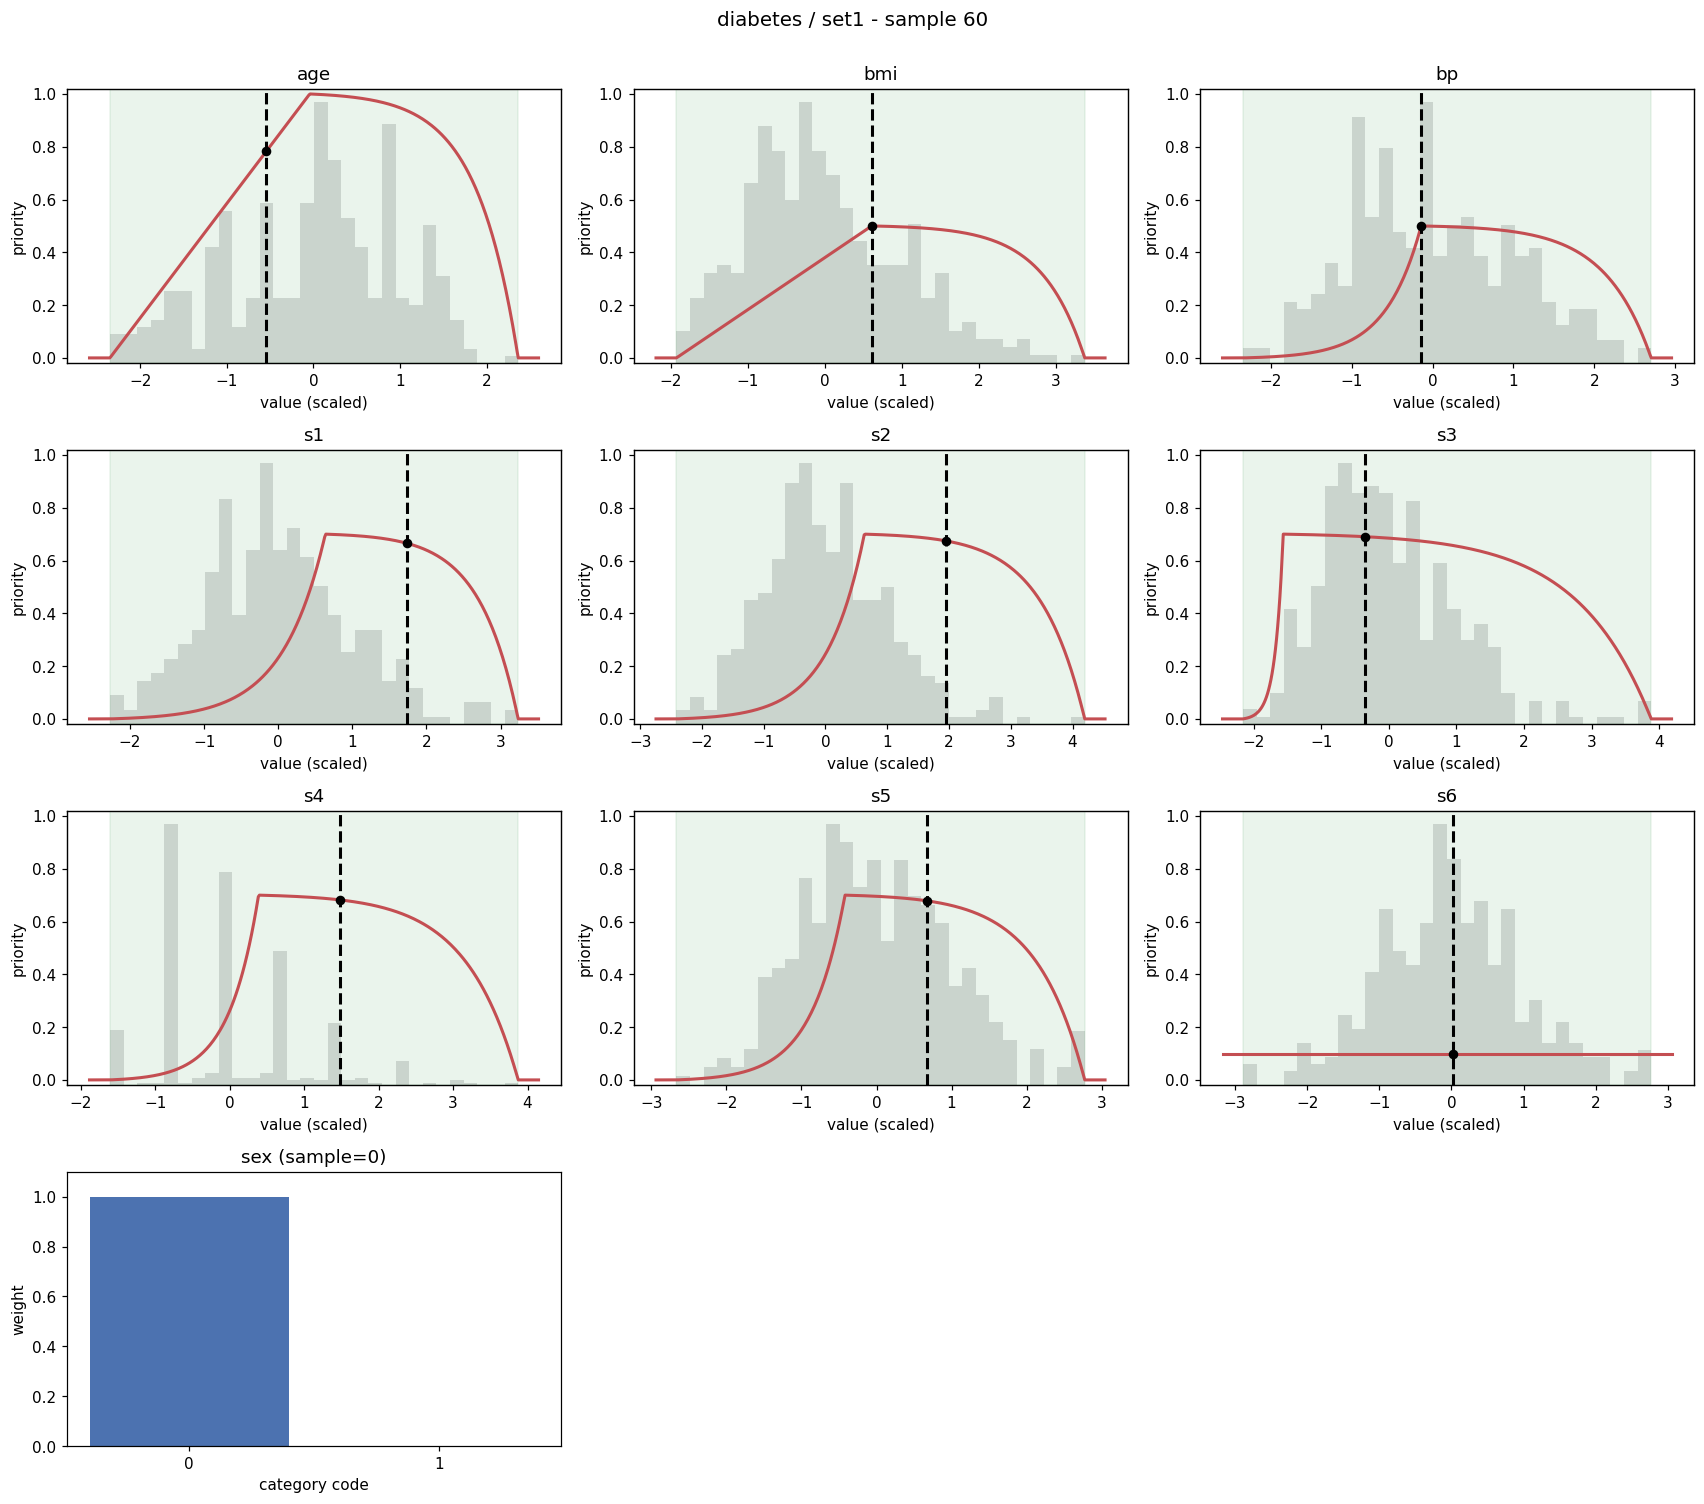

In [2]:
st = current()
ctx = st['ctx']; pri = st['priorities']; sample = st['sample']
num = pri['numerical']; cat = pri['categorical']

panels = []
for idx in sorted(num.keys()):
    panels.append(('num', idx))
for indices in cat.keys():
    panels.append(('cat', indices))

ncols = 3
nrows = int(np.ceil(len(panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, panel in zip(axes, panels):
    kind, key = panel
    if kind == 'num':
        idx = key
        fname = ctx.feature_names[idx]
        d = num[idx]
        col = ctx.X_train[:, idx].astype(float)
        dmin, dmax = float(col.min()), float(col.max())
        sv = float(sample[idx])
        lo = min(dmin, sv); hi = max(dmax, sv)
        pad = 0.05 * (hi - lo + 1e-9)
        xs = np.linspace(lo - pad, hi + pad, 400)
        axb = ax.twinx()
        axb.hist(col, bins=30, color='0.8', alpha=0.7, zorder=0)
        axb.set_yticks([])
        if d.get('function') is None:
            ax.axvline(sv, color='black', ls='--', lw=2)
            ax.text(0.5, 0.5, 'non-actionable\n(fixed at sample)', transform=ax.transAxes,
                    ha='center', va='center', fontsize=9, color='dimgray')
            ax.set_ylim(-0.02, 1.02)
        else:
            ys = _eval_fn(d['function'], xs)
            ax.plot(xs, ys, color='#C44E52', lw=2, zorder=3)
            ax.axvspan(float(d['min']), float(d['max']), color='#55A868', alpha=0.12, zorder=1)
            ax.axvline(sv, color='black', ls='--', lw=2, zorder=4)
            sw = float(np.asarray(d['function'](sv)).squeeze())
            ax.scatter([sv], [sw], color='black', s=28, zorder=5)
            ax.set_ylim(-0.02, 1.02)
        ax.set_zorder(axb.get_zorder() + 1)
        ax.patch.set_visible(False)
        ax.set_title(fname)
        ax.set_xlabel('value (scaled)'); ax.set_ylabel('priority')
    else:
        indices = key
        fname = _group_name(ctx, indices)
        mapping = cat[indices]
        g = ctx.categorical_groups[fname]
        categories = list(g['categories'])
        sample_oh = tuple(float(sample[i]) for i in indices)
        sample_code = categories[int(np.argmax([sample[i] for i in indices]))]
        labels, heights, colors, hatches = [], [], [], []
        for c in categories:
            oh = tuple(1.0 if cc == c else 0.0 for cc in categories)
            w = mapping.get(oh)
            forbidden = w is None or w == 0
            labels.append(str(c))
            heights.append(0.0 if w is None else float(w))
            is_sample = (c == sample_code)
            colors.append('#4C72B0' if is_sample else ('#d9d9d9' if forbidden else '#8fa8cf'))
            hatches.append('xx' if forbidden else '')
        xpos = np.arange(len(categories))
        bars = ax.bar(xpos, heights, color=colors)
        for b, h in zip(bars, hatches):
            if h:
                b.set_hatch(h)
        ax.set_xticks(xpos); ax.set_xticklabels(labels)
        ax.set_ylim(0, max(1.0, max(heights) * 1.1 if heights else 1.0))
        ax.set_title(f'{fname} (sample={sample_code})')
        ax.set_xlabel('category code'); ax.set_ylabel('weight')

for ax in axes[len(panels):]:
    ax.set_visible(False)

fig.suptitle(f"{st['dataset_key']} / {st['set_name']} - sample {st['sample_idx']}", y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

## Part 3 - Priority score breakdown

The overall priority score is the sum of the per-feature weights evaluated at the sample (non-actionable numerical features do not contribute).

In [3]:
st = current()
ctx = st['ctx']; sample = st['sample']
breakdown = st['rs'].get_preference_breakdown(sample.tolist())
rows = []
for idx, info in breakdown['numerical'].items():
    rows.append({'feature': ctx.feature_names[idx], 'type': 'numerical',
                 'value': round(float(info['value']), 4),
                 'weight': (None if info['weight'] is None else round(float(info['weight']), 4)),
                 'actionable': info['actionable']})
for indices, info in breakdown['categorical'].items():
    rows.append({'feature': _group_name(ctx, indices), 'type': 'categorical',
                 'value': str(info['combination']),
                 'weight': round(float(info['weight']), 4), 'actionable': True})
df = pd.DataFrame(rows)
print(f"overall priority score = {breakdown['overall']:.4f}")
display(df)

overall priority score = 6.2738


,feature,type,value,weight,actionable
0,age,numerical,-0.5429,0.7831,True
1,bmi,numerical,0.608,0.5000,True
2,bp,numerical,-0.1415,0.5000,True
3,s6,numerical,0.0243,0.1000,True
4,s1,numerical,1.7377,0.6653,True
5,s2,numerical,1.9513,0.6745,True
6,s3,numerical,-0.3542,0.6903,True
7,s4,numerical,1.4843,0.6819,True
8,s5,numerical,0.6664,0.6787,True
9,sex,categorical,"(1.0, 0.0)",1.0000,True
